In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

Part 1: Data Preparation and Exploration

1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.


In [25]:
df = pd.read_csv(r"E:\DATA sCIENCE\Data set\exchange_rate.csv")
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [26]:
df['date'] = pd.to_datetime(df['date'].str.split().str[0], format = '%d-%m-%Y')
df

,date,Ex_rate
0,1990-01-01,0.785500
1,1990-01-02,0.781800
2,1990-01-03,0.786700
3,1990-01-04,0.786000
4,1990-01-05,0.784900
...,...,...
7583,2010-10-06,0.718494
7584,2010-10-07,0.721839
7585,2010-10-08,0.723197
7586,2010-10-09,0.720825


In [27]:
df.set_index('date', inplace=True)
df

,Ex_rate
date,
1990-01-01,0.785500
1990-01-02,0.781800
1990-01-03,0.786700
1990-01-04,0.786000
1990-01-05,0.784900
...,...
2010-10-06,0.718494
2010-10-07,0.721839
2010-10-08,0.723197


2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

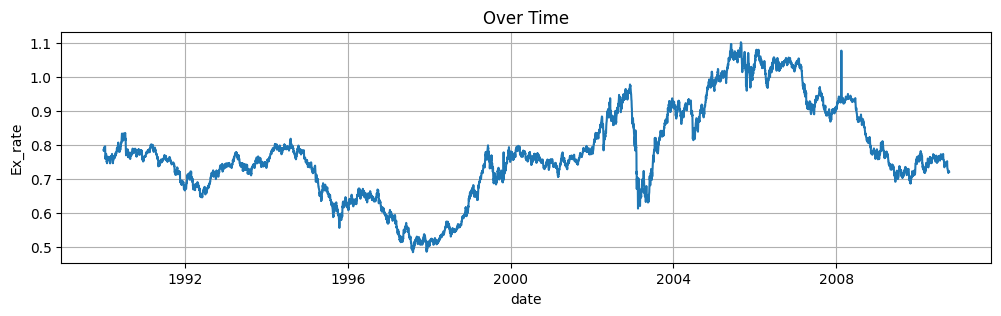

In [28]:
plt.figure(figsize=(12,3))
plt.plot(df)
plt.title('Over Time')
plt.xlabel('date')
plt.ylabel('Ex_rate')
plt.grid(True)
plt.show()

In [31]:
#stationarity check (ADF test)
def adf_test(series):
    result = adfuller(series)
    return{
        'ADF Statistic' : result[0],
        'p-value ' : result[1],
        'Critical Values' : result[4]
    }
adf_result_original = adf_test(df['Ex_rate'])
adf_result_original

{'ADF Statistic': np.float64(-1.6649941807381528),
 'p-value ': np.float64(0.4492327353597901),
 'Critical Values': {'1%': np.float64(-3.4312123140180137),
  '5%': np.float64(-2.861921078147796),
  '10%': np.float64(-2.5669728434336108)}}

In [ ]:
# Its shows that the value of p is greater than 0.05 that means series is not stationary. and 
#also the ADF statistic is -1.66 is in the 10% if the critrical value so the series is not statinary.

In [38]:
df['Ex_rate'] = df['Ex_rate'].diff()
df = df.dropna()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13952\1682594360.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ex_rate'] = df['Ex_rate'].diff()


In [39]:
df = df.iloc[1:]
df

,Ex_rate
date,
1990-01-06,-2.000000e-03
1990-01-07,-5.700000e-03
1990-01-08,2.600000e-03
1990-01-09,-1.110223e-16
1990-01-10,-8.000000e-03
...,...
2010-10-06,4.758000e-03
2010-10-07,2.430000e-04
2010-10-08,-8.264000e-03


In [40]:
adf_result_original = adf_test(df['Ex_rate'])
adf_result_original

{'ADF Statistic': np.float64(-38.99854687934005),
 'p-value ': 0.0,
 'Critical Values': {'1%': np.float64(-3.4312168865471473),
  '5%': np.float64(-2.861923098568134),
  '10%': np.float64(-2.566973918930586)}}

3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

In [10]:
df.isnull().sum() # in the data set there is no null value present

Ex_rate    0
data       0
dtype: int64

Part 2: Model Building - ARIMA

1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.


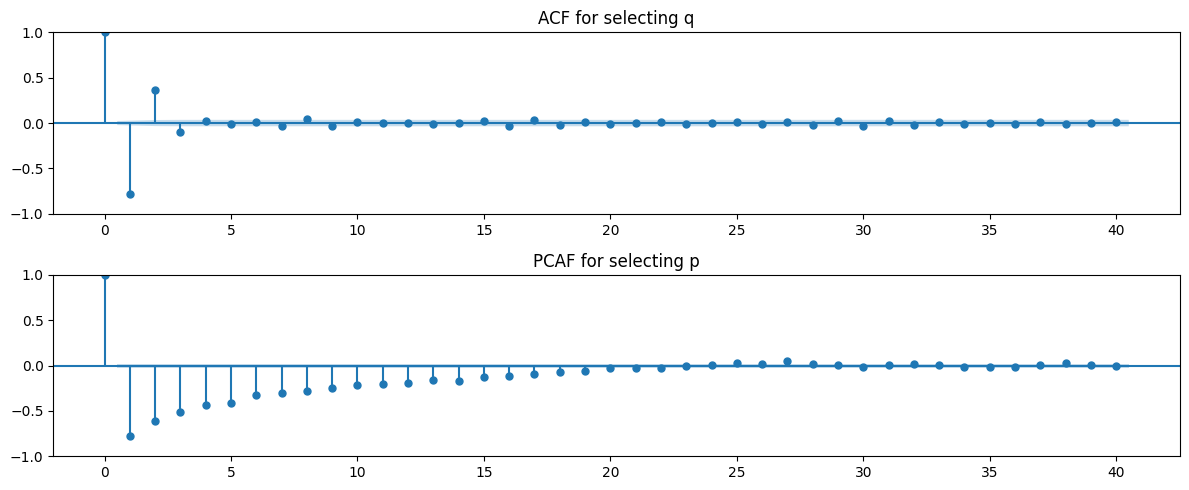

In [44]:
plt.figure(figsize = (12,5))
plt.subplot(2,1,1)
plot_acf(df, lags=40, ax=plt.gca(), title="ACF for selecting q")
plt.subplot(2,1,2)
plot_pacf(df, lags=40, ax=plt.gca(), title='PCAF for selecting p', method='ywm')
plt.tight_layout()
plt.show()

2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.



In [45]:
arima_model = ARIMA(df['Ex_rate'], order=(1,1,1))
arima_model_fit = arima_model.fit()
arima_model_fit.summary()

C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Lenovo\AppData\Loc

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Ex_rate   No. Observations:                 7583
Model:                 ARIMA(1, 1, 1)   Log Likelihood               19399.646
Date:                Fri, 21 Nov 2025   AIC                         -38793.292
Time:                        12:56:02   BIC                         -38772.491
Sample:                    01-06-1990   HQIC                        -38786.153
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7772      0.001   -721.664      0.000      -0.779      -0.775
ma.L1         -0.9999      0.120     -8.359      0.000      -1.234      -0.765
sigma2         0.0003   4.18e-05      8.377      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                1739.29   Jarque-Bera (JB):           4763557.89
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               3.72   Skew:                            -1.46
Prob(H) (two-sided):                  0.00   Kurtosis:                       125.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.


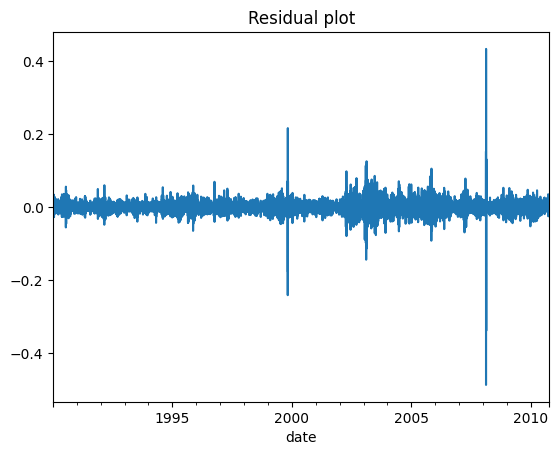

In [48]:
residuals = arima_model_fit.resid
residuals.plot()
plt.title("Residual plot")
plt.show()

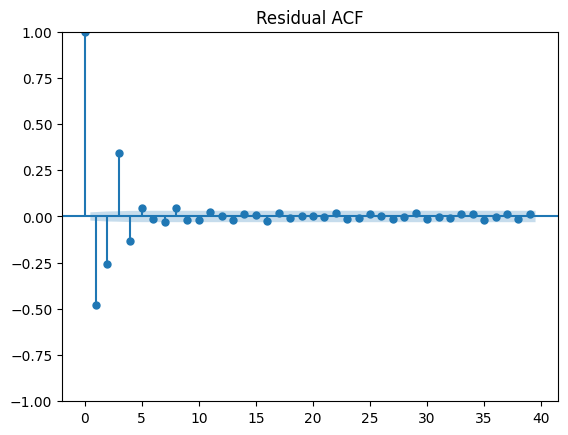

In [49]:
plot_acf(residuals)
plt.title("Residual ACF")
plt.show()

4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.


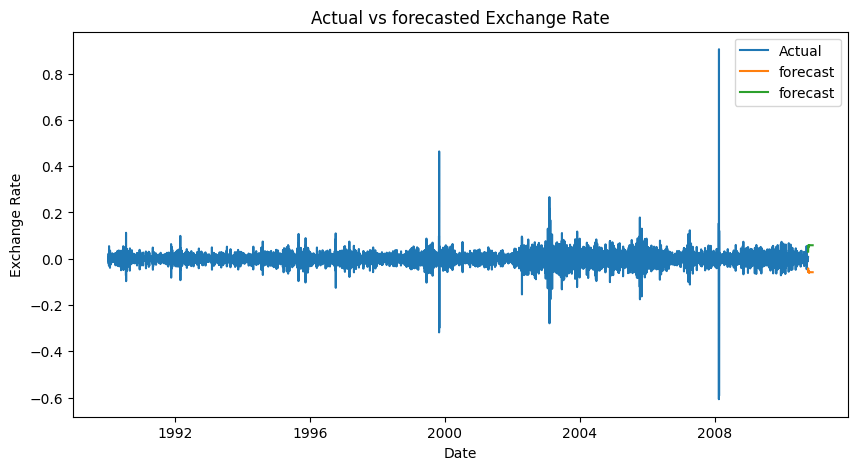

In [50]:
forecast_steps = 50
forecast = arima_model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.conf_int()

plt.figure(figsize=(10,5))
plt.plot(df['Ex_rate'], label='Actual')
plt.plot(forecast_mean.index, forecast_mean, label='forecast')
plt.title("Actual vs forecasted Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Part 3: Evaluation and Comparison

1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.


In [51]:
train_size = int(len(df) * 0.8)
train, test = df['Ex_rate'][:train_size], df['Ex_rate'][train_size:]

forecast = arima_model_fit.forecast(steps=len(test))

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

In [52]:
print("MAE :", mae)
print("RMSE :", rmse)

MAE : 0.01727391152599294
RMSE : 0.03867865481765265


In [ ]:
# it shows that the MAE AND RMSE is very small so the predicted value is close to the actual value the the arima works well our model is good

2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

-> Model Performmance:- ARIMA performed well with low MAE/RMSE, indicating good short-term accuracy.
Residual diagnostics show no major autocorrelation → the model fits the data well.

Model Advantages:- Captures trends and autocorrelation effectively and produces reliable short-term forecasts.

Model Limitations:- Not good with strong seasonality and Nnt ideal for long-term forecasting.

3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset
  
-> The ARIMA model worked very well for predicting the exchange rate. It gave accurate results with very small errors, based on the MAE and RMSE values. Overall, ARIMA was the best model for this dataset and provided stable, reliable predictions.